In [178]:
# For text processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import numpy as np

from scipy.stats import chi2_contingency

# For data manipulation
import pandas as pd

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns
import re 
# For machine learning
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier




In [151]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable


In [152]:
!pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable


In [153]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [154]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [155]:
file_path = '/home/izuchukwu/Downloads/buzzfeed/BuzzFeed_real_news_content.csv'
real_news = pd.read_csv(file_path)


In [156]:
real_news.head()



,id,title,text,url,top_img,authors,source,publish_date,movies,images,canonical_link,meta_data
0,Real_1-Webpage,Another Terrorist Attack in NYC…Why Are we STI...,"On Saturday, September 17 at 8:30 pm EST, an e...",http://eaglerising.com/36942/another-terrorist...,http://eaglerising.com/wp-content/uploads/2016...,"View All Posts,Leonora Cravotta",http://eaglerising.com,{'$date': 1474528230000},NaN,http://constitution.com/wp-content/uploads/201...,http://eaglerising.com/36942/another-terrorist...,"{""description"": ""\u201cWe believe at this poin..."
1,Real_10-Webpage,"Donald Trump: Drugs a 'Very, Very Big Factor' ...",Less than a day after protests over the police...,http://abcn.ws/2d4lNn9,http://a.abcnews.com/images/Politics/AP_donald...,"More Candace,Adam Kelsey,Abc News,More Adam",http://abcn.ws,NaN,NaN,http://www.googleadservices.com/pagead/convers...,http://abcnews.go.com/Politics/donald-trump-dr...,"{""fb_title"": ""Trump: Drugs a 'Very, Very Big F..."
2,Real_11-Webpage,"Obama To UN: ‘Giving Up Liberty, Enhances Secu...","Obama To UN: ‘Giving Up Liberty, Enhances Secu...",http://rightwingnews.com/barack-obama/obama-un...,http://rightwingnews.com/wp-content/uploads/20...,Cassy Fiano,http://rightwingnews.com,{'$date': 1474476044000},https://www.youtube.com/embed/ji6pl5Vwrvk,http://rightwingnews.com/wp-content/uploads/20...,http://rightwingnews.com/barack-obama/obama-un...,"{""googlebot"": ""noimageindex"", ""og"": {""site_nam..."
3,Real_12-Webpage,Trump vs. Clinton: A Fundamental Clash over Ho...,Getty Images Wealth Of Nations Trump vs. Clint...,http://politi.co/2de2qs0,http://static.politico.com/e9/11/6144cdc24e319...,"Jack Shafer,Erick Trickey,Zachary Karabell",http://politi.co,{'$date': 1474974420000},NaN,https://static.politico.com/dims4/default/8a1c...,http://www.politico.com/magazine/story/2016/09...,"{""description"": ""He sees it as zero-sum. She b..."
4,Real_13-Webpage,"President Obama Vetoes 9/11 Victims Bill, Sett...",President Obama today vetoed a bill that would...,http://abcn.ws/2dh2NFs,http://a.abcnews.com/images/US/AP_Obama_BM_201...,"John Parkinson,More John,Abc News,More Alexander",http://abcn.ws,NaN,NaN,http://www.googleadservices.com/pagead/convers...,http://abcnews.go.com/Politics/president-obama...,"{""fb_title"": ""President Obama Vetoes 9/11 Vict..."


In [157]:
file_path2= '/home/izuchukwu/Downloads/buzzfeed/BuzzFeed_fake_news_content.csv'
fake_news= pd.read_csv(file_path2)

In [158]:
fake_news.head()

,id,title,text,url,top_img,authors,source,publish_date,movies,images,canonical_link,meta_data
0,Fake_1-Webpage,Proof The Mainstream Media Is Manipulating The...,I woke up this morning to find a variation of ...,http://www.addictinginfo.org/2016/09/19/proof-...,http://addictinginfo.addictinginfoent.netdna-c...,Wendy Gittleson,http://www.addictinginfo.org,{'$date': 1474243200000},NaN,"http://i.imgur.com/JeqZLhj.png,http://addictin...",http://addictinginfo.com/2016/09/19/proof-the-...,"{""publisher"": ""Addicting Info | The Knowledge ..."
1,Fake_10-Webpage,Charity: Clinton Foundation Distributed “Water...,Former President Bill Clinton and his Clinton ...,http://eaglerising.com/36899/charity-clinton-f...,http://eaglerising.com/wp-content/uploads/2016...,View All Posts,http://eaglerising.com,{'$date': 1474416521000},NaN,http://constitution.com/wp-content/uploads/201...,http://eaglerising.com/36899/charity-clinton-f...,"{""description"": ""The possibility that CHAI dis..."
2,Fake_11-Webpage,A Hillary Clinton Administration May be Entire...,After collapsing just before trying to step in...,http://eaglerising.com/36880/a-hillary-clinton...,http://eaglerising.com/wp-content/uploads/2016...,"View All Posts,Tony Elliott",http://eaglerising.com,{'$date': 1474416638000},NaN,http://constitution.com/wp-content/uploads/201...,http://eaglerising.com/36880/a-hillary-clinton...,"{""description"": ""Hillary Clinton may be the fi..."
3,Fake_12-Webpage,Trump’s Latest Campaign Promise May Be His Mos...,"Donald Trump is, well, deplorable. He’s sugges...",http://www.addictinginfo.org/2016/09/19/trumps...,http://addictinginfo.addictinginfoent.netdna-c...,John Prager,http://www.addictinginfo.org,{'$date': 1474243200000},NaN,"http://i.imgur.com/JeqZLhj.png,http://2.gravat...",http://addictinginfo.com/2016/09/19/trumps-lat...,"{""publisher"": ""Addicting Info | The Knowledge ..."
4,Fake_13-Webpage,Website is Down For Maintenance,Website is Down For Maintenance,http://www.proudcons.com/clinton-foundation-ca...,NaN,NaN,http://www.proudcons.com,NaN,NaN,NaN,NaN,"{""og"": {""url"": ""http://www.proudcons.com"", ""ty..."


In [159]:
news_df = pd.concat([real_news, fake_news], ignore_index=True)


news_df['type'] = news_df['id'].str.split('_').str[0]




#merged both frames into one, added a new column to cateorize as real or fake

In [160]:
news_df.head()

,id,title,text,url,top_img,authors,source,publish_date,movies,images,canonical_link,meta_data,type
0,Real_1-Webpage,Another Terrorist Attack in NYC…Why Are we STI...,"On Saturday, September 17 at 8:30 pm EST, an e...",http://eaglerising.com/36942/another-terrorist...,http://eaglerising.com/wp-content/uploads/2016...,"View All Posts,Leonora Cravotta",http://eaglerising.com,{'$date': 1474528230000},NaN,http://constitution.com/wp-content/uploads/201...,http://eaglerising.com/36942/another-terrorist...,"{""description"": ""\u201cWe believe at this poin...",Real
1,Real_10-Webpage,"Donald Trump: Drugs a 'Very, Very Big Factor' ...",Less than a day after protests over the police...,http://abcn.ws/2d4lNn9,http://a.abcnews.com/images/Politics/AP_donald...,"More Candace,Adam Kelsey,Abc News,More Adam",http://abcn.ws,NaN,NaN,http://www.googleadservices.com/pagead/convers...,http://abcnews.go.com/Politics/donald-trump-dr...,"{""fb_title"": ""Trump: Drugs a 'Very, Very Big F...",Real
2,Real_11-Webpage,"Obama To UN: ‘Giving Up Liberty, Enhances Secu...","Obama To UN: ‘Giving Up Liberty, Enhances Secu...",http://rightwingnews.com/barack-obama/obama-un...,http://rightwingnews.com/wp-content/uploads/20...,Cassy Fiano,http://rightwingnews.com,{'$date': 1474476044000},https://www.youtube.com/embed/ji6pl5Vwrvk,http://rightwingnews.com/wp-content/uploads/20...,http://rightwingnews.com/barack-obama/obama-un...,"{""googlebot"": ""noimageindex"", ""og"": {""site_nam...",Real
3,Real_12-Webpage,Trump vs. Clinton: A Fundamental Clash over Ho...,Getty Images Wealth Of Nations Trump vs. Clint...,http://politi.co/2de2qs0,http://static.politico.com/e9/11/6144cdc24e319...,"Jack Shafer,Erick Trickey,Zachary Karabell",http://politi.co,{'$date': 1474974420000},NaN,https://static.politico.com/dims4/default/8a1c...,http://www.politico.com/magazine/story/2016/09...,"{""description"": ""He sees it as zero-sum. She b...",Real
4,Real_13-Webpage,"President Obama Vetoes 9/11 Victims Bill, Sett...",President Obama today vetoed a bill that would...,http://abcn.ws/2dh2NFs,http://a.abcnews.com/images/US/AP_Obama_BM_201...,"John Parkinson,More John,Abc News,More Alexander",http://abcn.ws,NaN,NaN,http://www.googleadservices.com/pagead/convers...,http://abcnews.go.com/Politics/president-obama...,"{""fb_title"": ""President Obama Vetoes 9/11 Vict...",Real


In [161]:
news_df.shape

(182, 13)

In [162]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              182 non-null    object
 1   title           182 non-null    object
 2   text            182 non-null    object
 3   url             174 non-null    object
 4   top_img         172 non-null    object
 5   authors         141 non-null    object
 6   source          174 non-null    object
 7   publish_date    133 non-null    object
 8   movies          25 non-null     object
 9   images          172 non-null    object
 10  canonical_link  170 non-null    object
 11  meta_data       182 non-null    object
 12  type            182 non-null    object
dtypes: object(13)
memory usage: 18.6+ KB


In [163]:
news_df.describe()

,id,title,text,url,top_img,authors,source,publish_date,movies,images,canonical_link,meta_data,type
count,182,182,182,174,172,141,174,133,25,172,170,182,182
unique,182,178,178,171,166,90,28,118,25,169,168,171,2
top,Real_1-Webpage,CNN’s Post-Debate Rigged Poll Busted…Here Are ...,We’re shocked — SHOCKED — to learn that CNN’s ...,http://eaglerising.com/36847/clinton-foundatio...,http://static.politico.com/da/f5/44342c424c68b...,Terresa Monroe-hamilton,http://politi.co,{'$date': 1474588800000},https://www.youtube.com/embed/ji6pl5Vwrvk,http://static.politico.com/da/f5/44342c424c68b...,http://eaglerising.com/36847/clinton-foundatio...,{},Real
freq,1,2,2,2,3,8,32,5,1,2,2,8,91


## 182 rows and 13 columns present
## Has no Na values

Cleandata

In [164]:
selected_columns = ["id", "title", "text", "source", "type", "images", "movies"]
news_df = news_df[selected_columns]
news_df.head()

# selected necessary columns to analyse

,id,title,text,source,type,images,movies
0,Real_1-Webpage,Another Terrorist Attack in NYC…Why Are we STI...,"On Saturday, September 17 at 8:30 pm EST, an e...",http://eaglerising.com,Real,http://constitution.com/wp-content/uploads/201...,NaN
1,Real_10-Webpage,"Donald Trump: Drugs a 'Very, Very Big Factor' ...",Less than a day after protests over the police...,http://abcn.ws,Real,http://www.googleadservices.com/pagead/convers...,NaN
2,Real_11-Webpage,"Obama To UN: ‘Giving Up Liberty, Enhances Secu...","Obama To UN: ‘Giving Up Liberty, Enhances Secu...",http://rightwingnews.com,Real,http://rightwingnews.com/wp-content/uploads/20...,https://www.youtube.com/embed/ji6pl5Vwrvk
3,Real_12-Webpage,Trump vs. Clinton: A Fundamental Clash over Ho...,Getty Images Wealth Of Nations Trump vs. Clint...,http://politi.co,Real,https://static.politico.com/dims4/default/8a1c...,NaN
4,Real_13-Webpage,"President Obama Vetoes 9/11 Victims Bill, Sett...",President Obama today vetoed a bill that would...,http://abcn.ws,Real,http://www.googleadservices.com/pagead/convers...,NaN


## I am going to change the "movies" and "images" column to categorical variables, "0" if not available and "1" if available

In [165]:
news_df['movies'] = news_df['movies'].notna().astype(int)
news_df['images'] = news_df['images'].notna().astype(int)

# I am ssuming that "addictinginfo.org" is one news source with different url
# so,I am combining all sources of "addictinginfo.org" into one 

In [166]:
fake_news['source'] = fake_news['source'].str.replace(r'www.addic|author.addic', 'addic', regex=True)
real_news['source'] = real_news['source'].str.replace(r'www.addic|author.addic', 'addic', regex=True)


In [167]:
news_df.head()

,id,title,text,source,type,images,movies
0,Real_1-Webpage,Another Terrorist Attack in NYC…Why Are we STI...,"On Saturday, September 17 at 8:30 pm EST, an e...",http://eaglerising.com,Real,1,0
1,Real_10-Webpage,"Donald Trump: Drugs a 'Very, Very Big Factor' ...",Less than a day after protests over the police...,http://abcn.ws,Real,1,0
2,Real_11-Webpage,"Obama To UN: ‘Giving Up Liberty, Enhances Secu...","Obama To UN: ‘Giving Up Liberty, Enhances Secu...",http://rightwingnews.com,Real,1,1
3,Real_12-Webpage,Trump vs. Clinton: A Fundamental Clash over Ho...,Getty Images Wealth Of Nations Trump vs. Clint...,http://politi.co,Real,1,0
4,Real_13-Webpage,"President Obama Vetoes 9/11 Victims Bill, Sett...",President Obama today vetoed a bill that would...,http://abcn.ws,Real,1,0


/tmp/ipykernel_9011/2821222016.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=source_counts, y='source', x='count', palette='Greens_d')


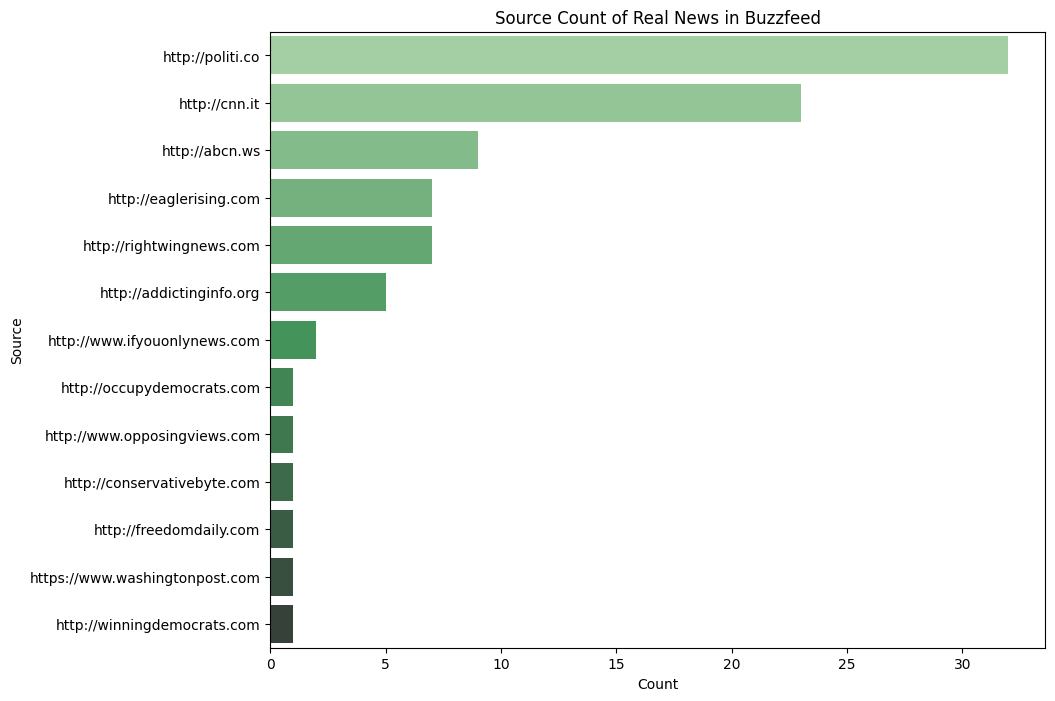

In [168]:
source_counts = real_news['source'].value_counts().reset_index()
source_counts.columns = ['source', 'count']

plt.figure(figsize=(10, 8))
sns.barplot(data=source_counts, y='source', x='count', palette='Greens_d')
plt.title('Source Count of Real News in Buzzfeed')
plt.xlabel('Count')
plt.ylabel('Source')
plt.show()


/tmp/ipykernel_9011/2679658194.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=source_counts_fake, y='source', x='count', palette='Reds_d')


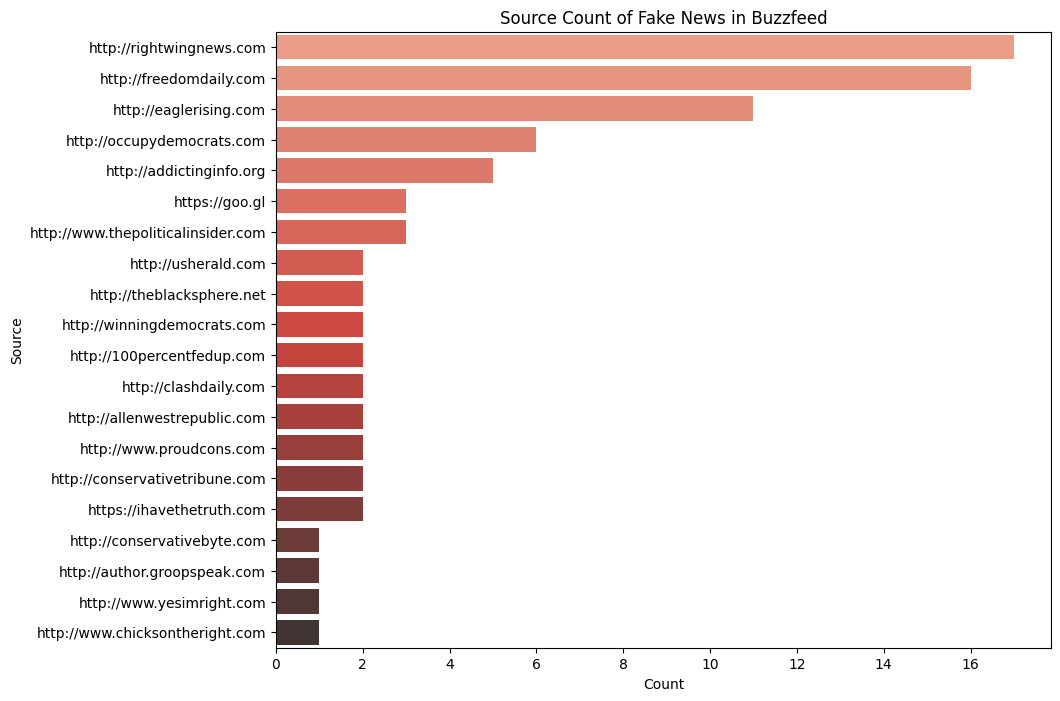

In [169]:
source_counts_fake = fake_news['source'].value_counts().reset_index()
source_counts_fake.columns = ['source', 'count']


plt.figure(figsize=(10, 8))
sns.barplot(data=source_counts_fake, y='source', x='count', palette='Reds_d')
plt.title('Source Count of Fake News in Buzzfeed')
plt.xlabel('Count')
plt.ylabel('Source')
plt.show()

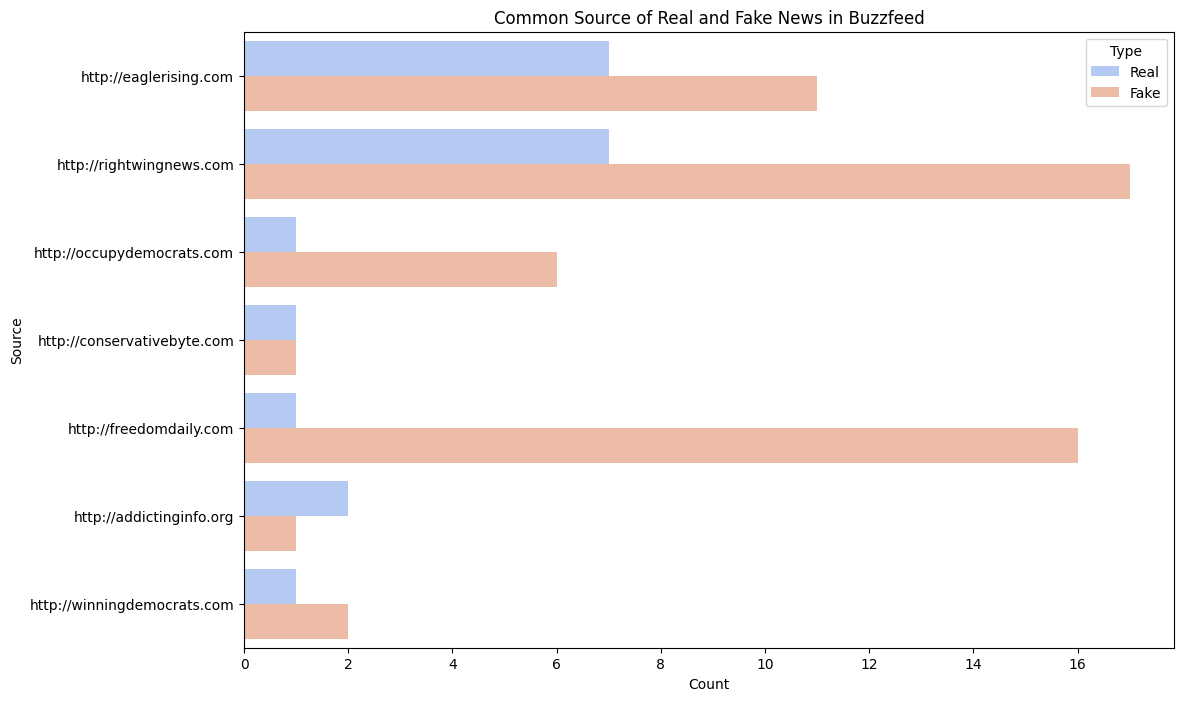

In [170]:
common_source = set(real_news['source']).intersection(set(fake_news['source']))

filtered_news_df = news_df[news_df['source'].isin(common_source)]

plt.figure(figsize=(12, 8))
sns.countplot(data=filtered_news_df, y='source', hue='type', palette='coolwarm', dodge=True)
plt.title('Common Source of Real and Fake News in Buzzfeed')
plt.xlabel('Count')
plt.ylabel('Source')
plt.legend(title='Type')
plt.show()

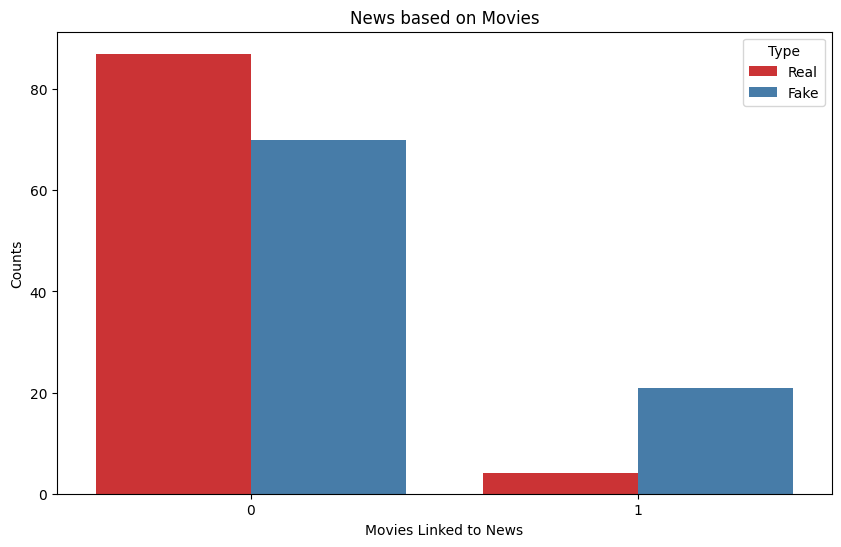

In [171]:
news_df['movies'] = news_df['movies'].astype('category')

plt.figure(figsize=(10, 6))
sns.countplot(data=news_df, x='movies', hue='type', palette='Set1', dodge=True)
plt.xlabel('Movies Linked to News')
plt.ylabel('Counts')
plt.title('News based on Movies')
plt.legend(title='Type')
plt.show()

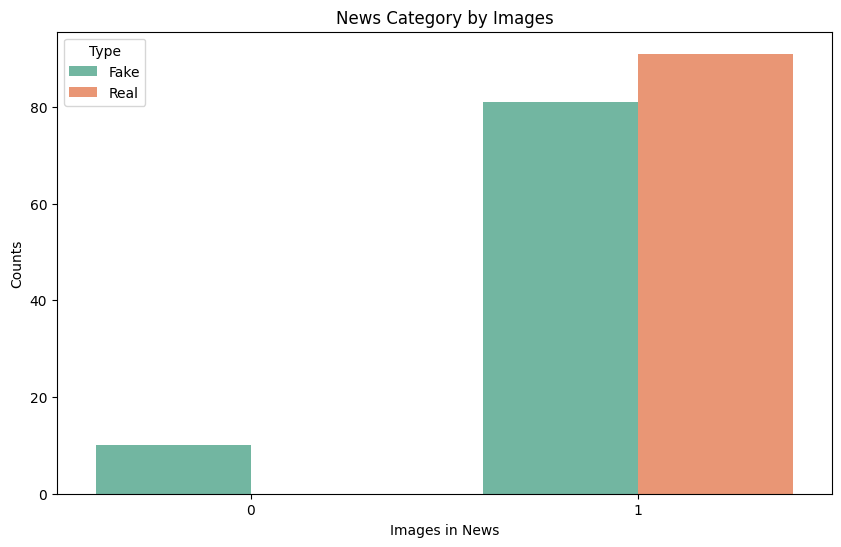

In [172]:
plt.figure(figsize=(10, 6))
sns.countplot(data=news_df, x='images', hue='type', palette='Set2', dodge=True)
plt.xlabel('Images in News')
plt.ylabel('Counts')
plt.title('News Category by Images')
plt.legend(title='Type')
plt.show()

In [173]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/izuchukwu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/izuchukwu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [179]:
stemmer = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))


In [180]:
def clean_text(text):
    """Remove special characters and unwanted symbols."""
    return re.sub(r'…|⋆|–|‹|”|“|‘|’', ' ', text)

def preprocess_text(text):
    """Preprocess the text data."""
    # Convert the text to lower case
    text = text.lower()
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuations
    text = re.sub(r'[^\w\s]', '', text)
    # Remove special characters from text
    text = clean_text(text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and specific words
    tokens = [word for word in tokens if word not in stop_words and word not in ['eagle', 'rising', 'freedom', 'daily']]
    # 'Stem' words to root words
    tokens = [stemmer.stem(word) for word in tokens]
    # Reassemble text
    return ' '.join(tokens)

In [182]:
vectorizer = CountVectorizer(stop_words='english', preprocessor=preprocess_text)
X = vectorizer.fit_transform(news_df['title'])
X_matrix = X.toarray()

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/home/izuchukwu/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************
